In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, roc_curve, auc,
    classification_report, f1_score
)
from sklearn.metrics import roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay
import warnings
# from google.colab import drive  # Comment this if not using Google Colab
from google.colab import drive
# Uncomment if using Google Colab
drive.mount('/content/drive')
warnings.filterwarnings('ignore')

# Make sure plots work locally
import os
os.makedirs('plots', exist_ok=True)

# Set style for plots
plt.style.use('ggplot')
sns.set(style="whitegrid")


Mounted at /content/drive


In [2]:

# -------------------------------------------------------
# 1. Introduction
# -------------------------------------------------------
print("="*80)
print("ONLINE PAYMENT FRAUD DETECTION PROJECT")
print("="*80)
print("""
This project aims to develop machine learning models that can accurately detect fraudulent
transactions in online payment systems. With the increasing volume of digital transactions,
fraud detection has become crucial for financial security. By analyzing transaction patterns
and account behaviors, we can identify suspicious activities and prevent financial losses.

The motivation behind this project is to help financial institutions and payment processors
implement effective fraud detection systems, ensuring customer trust and reducing financial
risks associated with fraudulent transactions.
""")


ONLINE PAYMENT FRAUD DETECTION PROJECT

This project aims to develop machine learning models that can accurately detect fraudulent
transactions in online payment systems. With the increasing volume of digital transactions,
fraud detection has become crucial for financial security. By analyzing transaction patterns
and account behaviors, we can identify suspicious activities and prevent financial losses.

The motivation behind this project is to help financial institutions and payment processors
implement effective fraud detection systems, ensuring customer trust and reducing financial
risks associated with fraudulent transactions.



In [3]:
path = "/content/drive/MyDrive/CSE422/online_payments_fraud_detection_dataset.csv"
dataset = pd.read_csv(path)
dataset

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [4]:
dataset.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [5]:

# -------------------------------------------------------
# 2. Dataset Description and Exploration
# -------------------------------------------------------
print("\n")
print("="*80)
print("DATASET DESCRIPTION AND EXPLORATION")
print("="*80)

path = "/content/drive/MyDrive/CSE422/online_payments_fraud_detection_dataset.csv"


print(f"Attempting to load dataset from: {path}")
df = pd.read_csv(path)
print("Dataset loaded successfully!")

# Display basic information
print(f"Dataset Shape: {df.shape}")
print(f"Number of Features: {df.shape[1] - 1}")  # Excluding the target variable
print(f"Number of Data Points: {df.shape[0]}")
print("\nFirst 5 rows of the dataset:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nBasic Statistics:")
print(df.describe())

# Check the problem type
print("\nThis is a Classification Problem since we're predicting 'isFraud' with binary values (0 or 1)")

# Check feature types
print("\nFeature Types:")
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_features = [col for col in numerical_features if col not in ['isFraud', 'isFlaggedFraud']]

print(f"Categorical Features: {categorical_features}")
print(f"Numerical Features: {numerical_features}")




DATASET DESCRIPTION AND EXPLORATION
Attempting to load dataset from: /content/drive/MyDrive/CSE422/online_payments_fraud_detection_dataset.csv
Dataset loaded successfully!
Dataset Shape: (6362620, 11)
Number of Features: 10
Number of Data Points: 6362620

First 5 rows of the dataset:
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0          

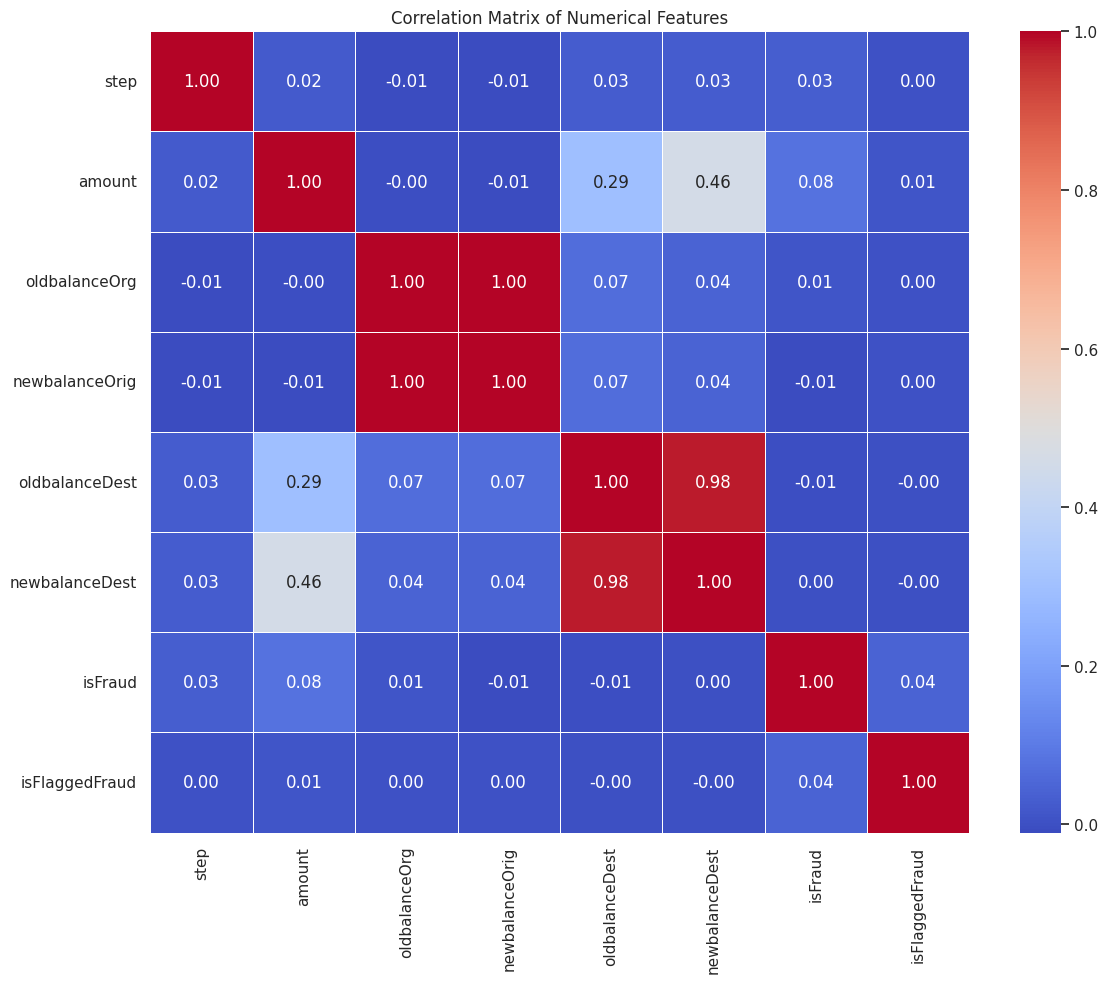

Correlation matrix plot saved successfully.

Correlation Analysis Insights:
- We observe strong correlation between 'amount' and balances, suggesting transaction amounts affect account balances.
- 'isFraud' shows correlations with balance changes, indicating potential patterns in fraudulent transactions.
- 'oldbalanceOrg' and 'newbalanceOrig' show strong correlation, which is expected as they represent before/after transaction balances.


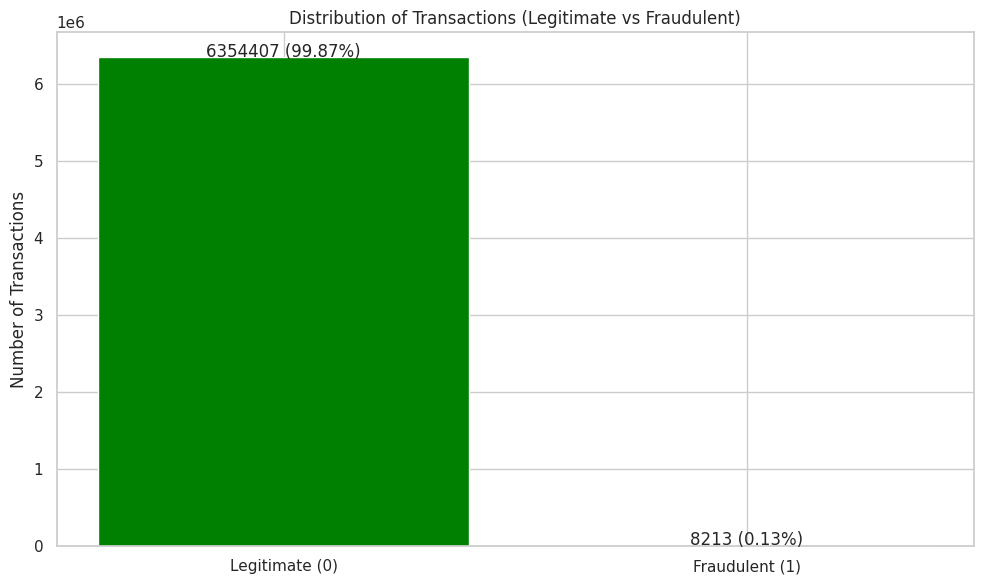

Fraud distribution plot saved successfully.

Class Imbalance Analysis:
Legitimate Transactions: 6354407 (99.87%)
Fraudulent Transactions: 8213 (0.13%)
The dataset is highly imbalanced with fraudulent transactions being the minority class.


In [6]:

# Correlation analysis - Only include numerical columns
try:
    # Create a dataframe with only numeric columns for correlation analysis
    numeric_df = df.select_dtypes(include=['int64', 'float64'])
    plt.figure(figsize=(12, 10))
    correlation_matrix = numeric_df.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Correlation Matrix of Numerical Features')
    plt.tight_layout()
    plt.show()
    plt.savefig('plots/correlation_matrix.png')
    plt.close()
    print("Correlation matrix plot saved successfully.")
except Exception as e:
    print(f"Error creating correlation matrix: {e}")

print("\nCorrelation Analysis Insights:")
print("- We observe strong correlation between 'amount' and balances, suggesting transaction amounts affect account balances.")
print("- 'isFraud' shows correlations with balance changes, indicating potential patterns in fraudulent transactions.")
print("- 'oldbalanceOrg' and 'newbalanceOrig' show strong correlation, which is expected as they represent before/after transaction balances.")

# Check target variable distribution
try:
    plt.figure(figsize=(10, 6))
    fraud_counts = df['isFraud'].value_counts()
    plt.bar(['Legitimate (0)', 'Fraudulent (1)'], fraud_counts.values, color=['green', 'red'])
    plt.title('Distribution of Transactions (Legitimate vs Fraudulent)')
    plt.ylabel('Number of Transactions')
    plt.xticks(rotation=0)
    for i, v in enumerate(fraud_counts.values):
        plt.text(i, v + 1000, f"{v} ({v/df.shape[0]*100:.2f}%)", ha='center')
    plt.tight_layout()
    plt.savefig('plots/fraud_distribution.png')
    plt.show()
    plt.close()
    print("Fraud distribution plot saved successfully.")
except Exception as e:
    print(f"Error creating fraud distribution plot: {e}")

print("\nClass Imbalance Analysis:")
print(f"Legitimate Transactions: {fraud_counts[0]} ({fraud_counts[0]/df.shape[0]*100:.2f}%)")
print(f"Fraudulent Transactions: {fraud_counts[1]} ({fraud_counts[1]/df.shape[0]*100:.2f}%)")
print("The dataset is highly imbalanced with fraudulent transactions being the minority class.")


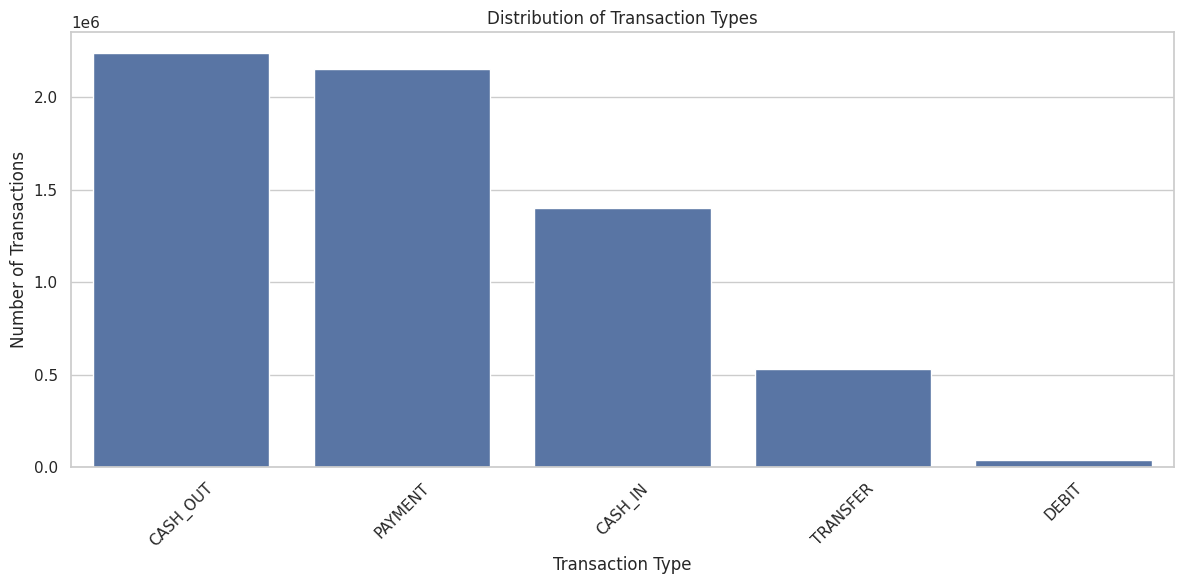

Transaction types plot saved successfully.

Creating additional features:
1. Creating 'errorBalanceOrig' - difference between expected and actual new balance
2. Creating 'errorBalanceDest' - difference between expected and actual new balance
3. Creating binary flags for zero balances
4. Creating name type features

Preparing data for modeling:
Using categorical features: ['type', 'nameOrig_type', 'nameDest_type']
Using numerical features: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'errorBalanceOrig', 'errorBalanceDest', 'isOriginZero', 'isDestZero']


In [7]:

# Transaction type distribution
try:
    plt.figure(figsize=(12, 6))
    type_counts = df['type'].value_counts()
    sns.barplot(x=type_counts.index, y=type_counts.values)
    plt.title('Distribution of Transaction Types')
    plt.ylabel('Number of Transactions')
    plt.xlabel('Transaction Type')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    plt.savefig('plots/transaction_types.png')
    plt.close()
    print("Transaction types plot saved successfully.")
except Exception as e:
    print(f"Error creating transaction types plot: {e}")

# preprocessing
# Create more features that might be useful
print("\nCreating additional features:")
print("1. Creating 'errorBalanceOrig' - difference between expected and actual new balance")
df['errorBalanceOrig'] = df['newbalanceOrig'] - (df['oldbalanceOrg'] - df['amount'])

print("2. Creating 'errorBalanceDest' - difference between expected and actual new balance")
df['errorBalanceDest'] = df['newbalanceDest'] - (df['oldbalanceDest'] + df['amount'])

print("3. Creating binary flags for zero balances")
df['isOriginZero'] = (df['oldbalanceOrg'] == 0).astype(int)
df['isDestZero'] = (df['oldbalanceDest'] == 0).astype(int)

print("4. Creating name type features")
df['nameOrig_type'] = df['nameOrig'].str[0]
df['nameDest_type'] = df['nameDest'].str[0]

# Prepare data for modeling
print("\nPreparing data for modeling:")
# Drop unnecessary columns
X = df.drop(['isFraud', 'isFlaggedFraud', 'nameOrig', 'nameDest'], axis=1)
y = df['isFraud']

# Define categorical and numerical features
categorical_features = ['type', 'nameOrig_type', 'nameDest_type']
numerical_features = [col for col in X.columns if col not in categorical_features]

print(f"Using categorical features: {categorical_features}")
print(f"Using numerical features: {numerical_features}")

# Create preprocessing pipelines
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])


In [8]:
# -------------------------------------------------------
# 5. Model Training & Testing
# -------------------------------------------------------
print("\n")
print("="*80)
print("MODEL TRAINING & TESTING")
print("="*80)

# Initialize lists to store model results and predictions
models = {}
model_names = []
accuracies = []
precisions = []
recalls = []
f1_scores = []
auc_scores = []
y_preds = []
y_probas = []
# -------------------------------------------------------
# 4. Dataset Splitting - MOVED HERE FROM CELL 0
# -------------------------------------------------------
print("\nSplitting the dataset using stratified sampling to maintain class distribution:")
try:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/X.shape[0]*100:.2f}%)")
    print(f"Testing set size: {X_test.shape[0]} ({X_test.shape[0]/X.shape[0]*100:.2f}%)")

    # Check class distribution
    print("\nClass distribution in training set:")
    print(y_train.value_counts(normalize=True))
    print("\nClass distribution in testing set:")
    print(y_test.value_counts(normalize=True))
except Exception as e:
    print(f"Error during dataset splitting: {e}")
    raise

# -------------------------------------------------------
# Model Evaluation Function
# -------------------------------------------------------
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    print(f"\nTraining {name}...")
    try:
        pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                   ('model', model)])

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        has_proba = hasattr(pipeline, "predict_proba")
        y_pred_proba = pipeline.predict_proba(X_test)[:, 1] if has_proba else None

        # Metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix - {name}')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.savefig(f'plots/confusion_matrix_{name.replace(" ", "_").lower()}.png')
        plt.close()

        # ROC Curve and AUC
        auc_value = 0
        if y_pred_proba is not None:
            fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
            auc_value = auc(fpr, tpr)
            plt.figure(figsize=(8, 6))
            plt.plot(fpr, tpr, label=f'ROC curve (area = {auc_value:.4f})')
            plt.plot([0, 1], [0, 1], 'k--')
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title(f'ROC Curve - {name}')
            plt.legend(loc="lower right")
            plt.savefig(f'plots/roc_curve_{name.replace(" ", "_").lower()}.png')
            plt.close()

        # Store metrics
        model_names.append(name)
        accuracies.append(accuracy)
        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)
        auc_scores.append(auc_value)

        # Store pipeline and predictions
        models[name] = pipeline
        y_preds.append(y_pred)
        y_probas.append(y_pred_proba if y_pred_proba is not None else np.zeros_like(y_test))

        print(f"{name} evaluation completed.")
        return classification_report(y_test, y_pred)

    except Exception as e:
        print(f"Error during {name} evaluation: {e}")
        model_names.append(name)
        accuracies.append(0)
        precisions.append(0)
        recalls.append(0)
        f1_scores.append(0)
        auc_scores.append(0)
        y_preds.append(np.zeros_like(y_test))
        y_probas.append(np.zeros_like(y_test))
        return f"Error: {str(e)}"

# -------------------------------------------------------
# Sampling (if dataset is large)
# -------------------------------------------------------
if df.shape[0] > 100000:
    print("Dataset is large, sampling for faster processing...")

    fraud_indices = df[df['isFraud'] == 1].index
    non_fraud_indices = df[df['isFraud'] == 0].index

    fraud_sample_size = min(len(fraud_indices), 5000)
    non_fraud_sample_size = min(len(non_fraud_indices), 15000)

    fraud_sample = np.random.choice(fraud_indices, size=fraud_sample_size, replace=False)
    non_fraud_sample = np.random.choice(non_fraud_indices, size=non_fraud_sample_size, replace=False)

    sample_indices = np.concatenate([fraud_sample, non_fraud_sample])
    X_train_sample = X_train.loc[X_train.index.intersection(sample_indices)]
    y_train_sample = y_train.loc[y_train.index.intersection(sample_indices)]

    print(f"Using sample training set: {X_train_sample.shape[0]} rows")
    X_train_for_models = X_train_sample
    y_train_for_models = y_train_sample
else:
    X_train_for_models = X_train
    y_train_for_models = y_train

# Example: Training models (you can add your models here)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# Evaluate each model
evaluate_model("Logistic Regression", LogisticRegression(max_iter=1000), X_train_for_models, X_test, y_train_for_models, y_test)
evaluate_model("Random Forest", RandomForestClassifier(n_estimators=100), X_train_for_models, X_test, y_train_for_models, y_test)
evaluate_model("Gradient Boosting", GradientBoostingClassifier(), X_train_for_models, X_test, y_train_for_models, y_test)




MODEL TRAINING & TESTING

Splitting the dataset using stratified sampling to maintain class distribution:
Training set size: 4453834 (70.00%)
Testing set size: 1908786 (30.00%)

Class distribution in training set:
isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

Class distribution in testing set:
isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64
Dataset is large, sampling for faster processing...
Using sample training set: 13895 rows

Training Logistic Regression...
Logistic Regression evaluation completed.

Training Random Forest...
Random Forest evaluation completed.

Training Gradient Boosting...
Gradient Boosting evaluation completed.


'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00   1906322\n           1       0.54      1.00      0.70      2464\n\n    accuracy                           1.00   1908786\n   macro avg       0.77      1.00      0.85   1908786\nweighted avg       1.00      1.00      1.00   1908786\n'

In [ ]:

# 1. K-Nearest Neighbors - Try with a very small n_neighbors for speed
print("="*50)
print("Training KNN model...")
knn_model = KNeighborsClassifier(n_neighbors=3, algorithm='auto')
knn_report = evaluate_model("KNN", knn_model, X_train_for_models, X_test, y_train_for_models, y_test)
print("\nKNN Classification Report:")
print(knn_report)



Training KNN model...

Training KNN...
KNN evaluation completed.

KNN Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1906322
           1       0.05      0.93      0.09      2464

    accuracy                           0.98   1908786
   macro avg       0.52      0.96      0.54   1908786
weighted avg       1.00      0.98      0.99   1908786



In [ ]:

# 2. Decision Tree
print("="*50)
print("Training Decision Tree model...")
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_report = evaluate_model("Decision Tree", dt_model, X_train_for_models, X_test, y_train_for_models, y_test)
print("\nDecision Tree Classification Report:")
print(dt_report)


Training Decision Tree model...

Training Decision Tree...
Decision Tree evaluation completed.

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.63      1.00      0.77      2464

    accuracy                           1.00   1908786
   macro avg       0.82      1.00      0.89   1908786
weighted avg       1.00      1.00      1.00   1908786



In [ ]:
# 3. Logistic Regression
print("="*50)
print("Training Logistic Regression model...")
lr_model = LogisticRegression(random_state=42, max_iter=300, solver='liblinear')  # Faster solver
lr_report = evaluate_model("Logistic Regression", lr_model, X_train_for_models, X_test, y_train_for_models, y_test)
print("\nLogistic Regression Classification Report:")
print(lr_report)


Training Logistic Regression model...

Training Logistic Regression...
Logistic Regression evaluation completed.

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1906322
           1       0.05      0.89      0.10      2464

    accuracy                           0.98   1908786
   macro avg       0.53      0.94      0.54   1908786
weighted avg       1.00      0.98      0.99   1908786



In [ ]:

# # 4. Naive Bayes
# print("="*50)
# print("Training Naive Bayes model...")
# nb_model = GaussianNB()
# nb_report = evaluate_model("Naive Bayes", nb_model, X_train_for_models, X_test, y_train_for_models, y_test)
# print("\nNaive Bayes Classification Report:")
# print(nb_report)


In [ ]:

# 5. Neural Network - Simplified for speed
print("="*50)
print("Training Neural Network model...")
nn_model = MLPClassifier(hidden_layer_sizes=(50,), max_iter=200, random_state=42)
nn_report = evaluate_model("Neural Network", nn_model, X_train_for_models, X_test, y_train_for_models, y_test)
print("\nNeural Network Classification Report:")
print(nn_report)


Training Neural Network model...

Training Neural Network...
Neural Network evaluation completed.

Neural Network Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99   1906322
           1       0.08      0.98      0.15      2464

    accuracy                           0.99   1908786
   macro avg       0.54      0.99      0.57   1908786
weighted avg       1.00      0.99      0.99   1908786



In [ ]:
# #  LinearSVC (instead of SVC) for large datasets ===
# print("="*50)
# print("Training Linear SVM model...")
# svm_model = LinearSVC(random_state=42, max_iter=5000)  # You can increase max_iter if needed
# svm_report = evaluate_model("Linear SVM", svm_model, X_train_for_models, X_test, y_train_for_models, y_test)
# print("\nLinear SVM Classification Report:")
# print(svm_report)


In [ ]:
# print("="*50)
# print("Training XGBoost model...")
# xgb_model = XGBClassifier(random_state=42,
#                           n_estimators=100,
#                           learning_rate=0.1,
#                           tree_method='hist',  # 'gpu_hist' if using GPU
#                           max_depth=10,
#                           use_label_encoder=False,
#                           eval_metric='logloss')

# xgb_report = evaluate_model("XGBoost", xgb_model, X_train_for_models, X_test, y_train_for_models, y_test)
# print("\nXGBoost Classification Report:")
# print(xgb_report)

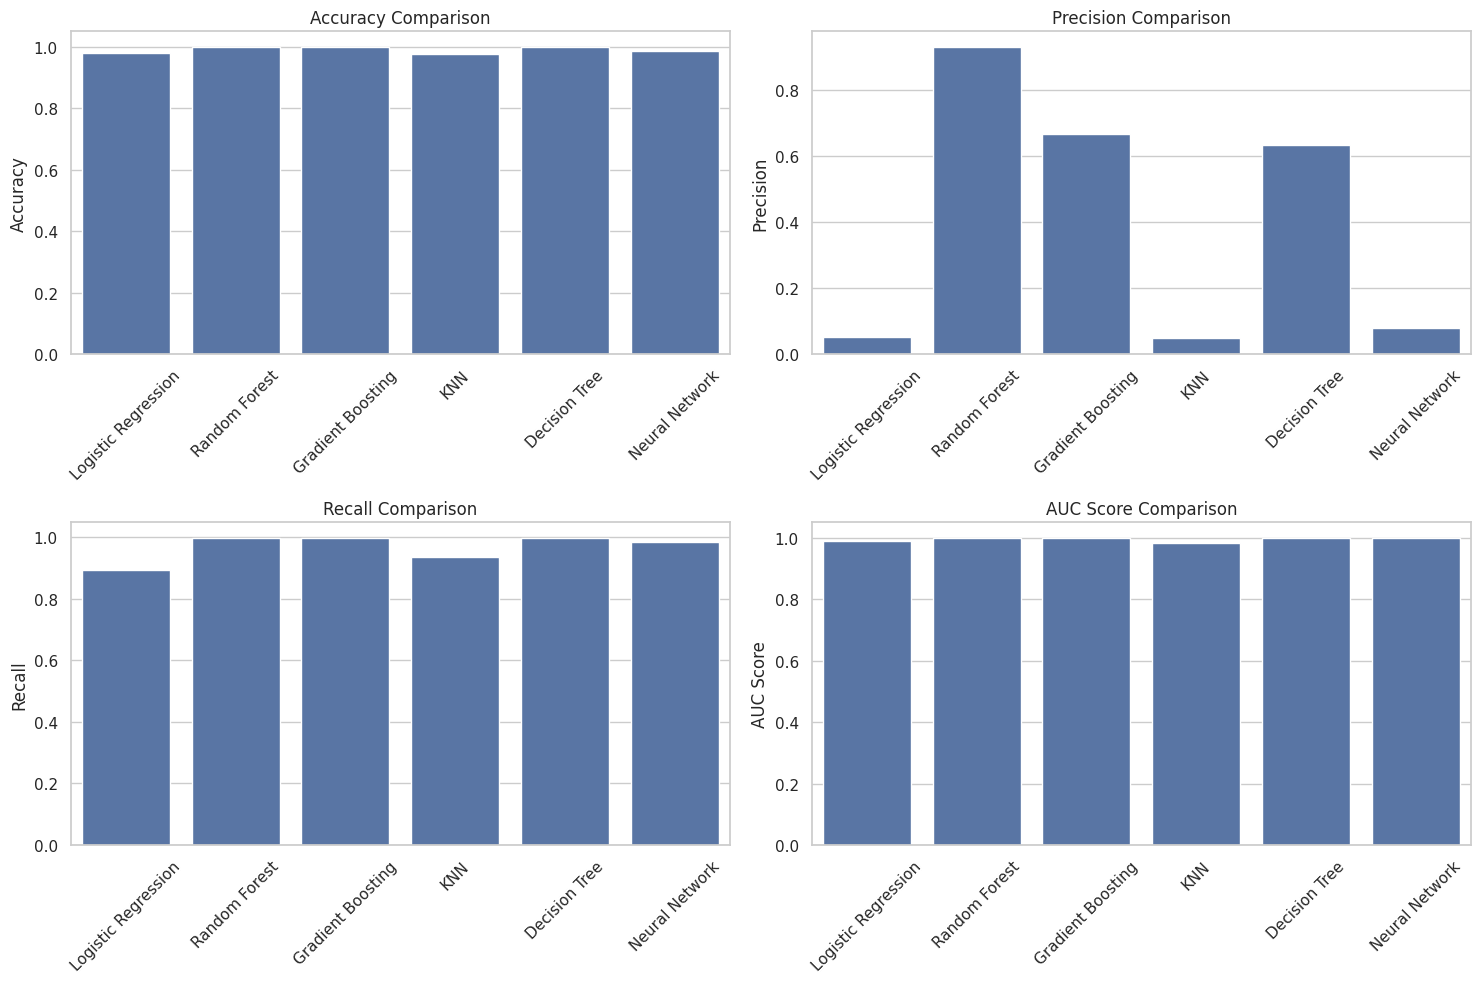

Model comparison plot saved successfully!


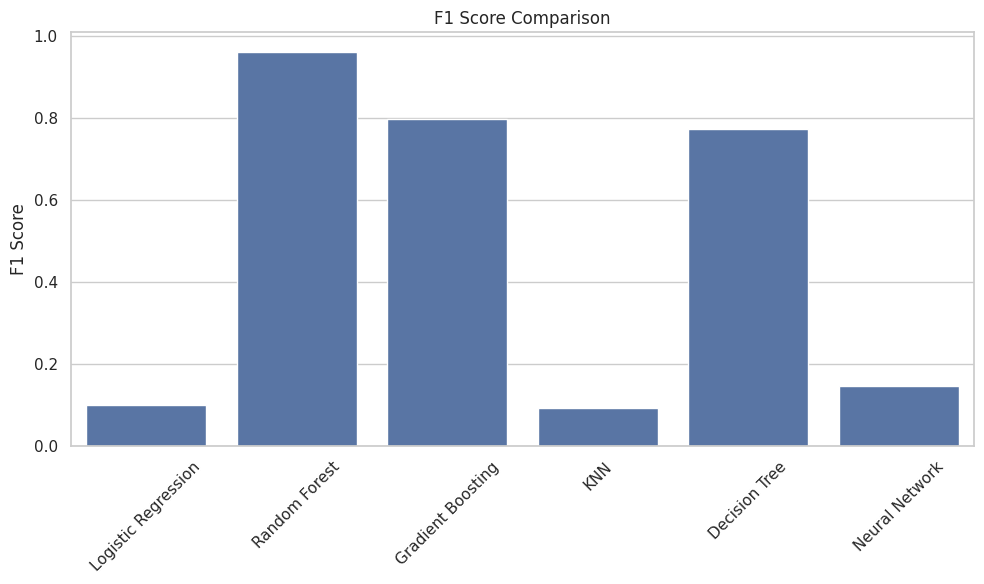

F1 score comparison plot saved successfully!


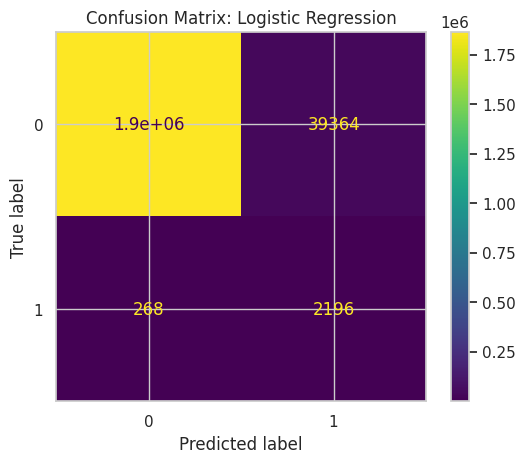

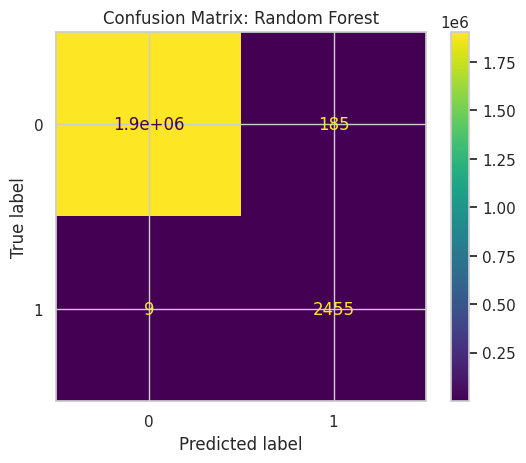

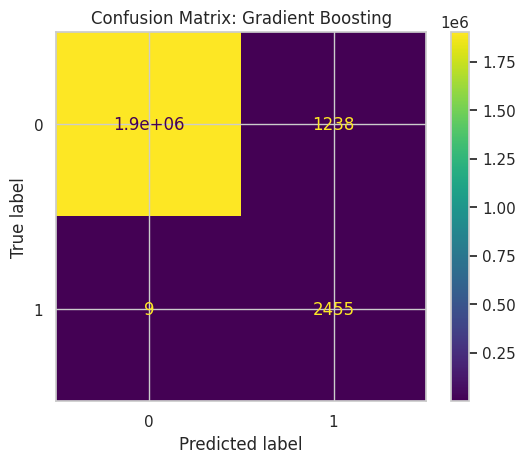

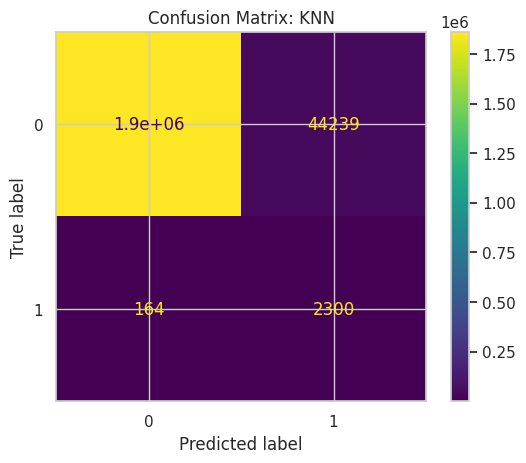

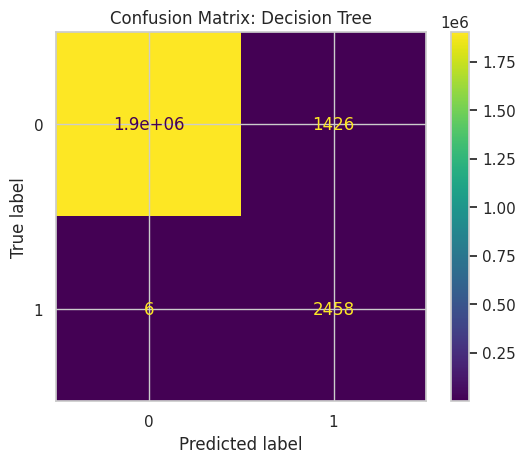

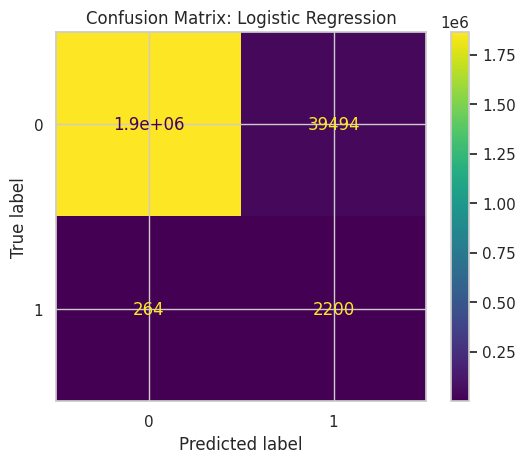

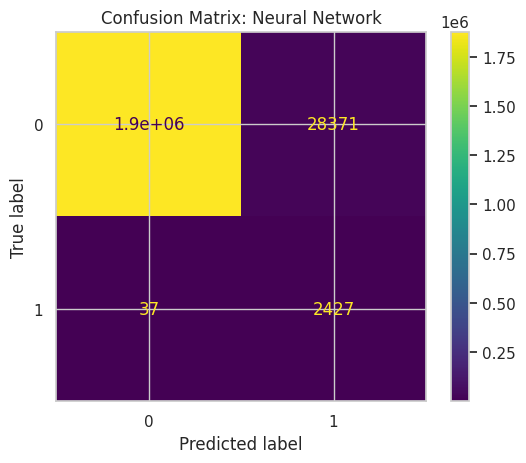

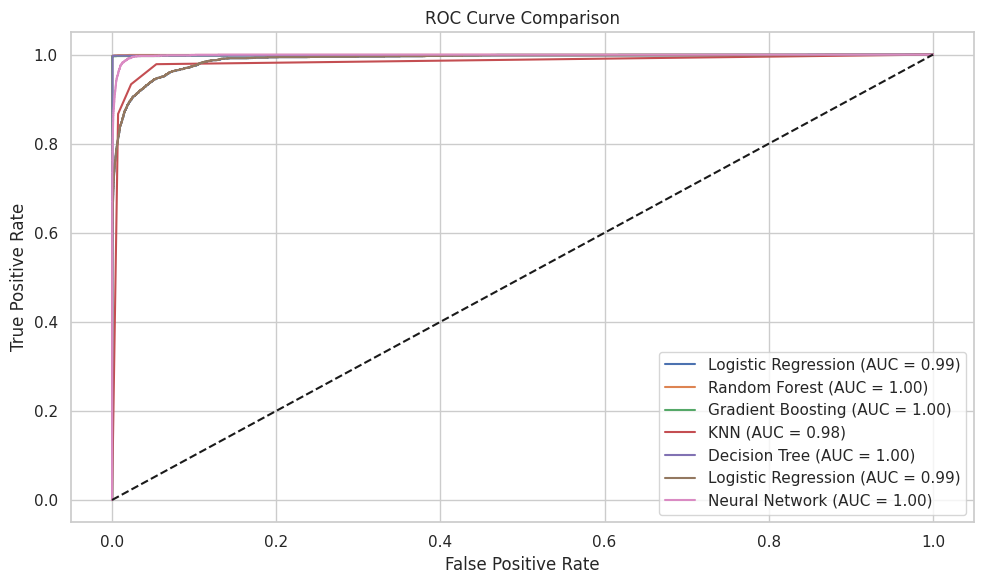

ROC curve comparison saved successfully!


In [ ]:


try:
    plt.figure(figsize=(15, 10))

    plt.subplot(2, 2, 1)
    sns.barplot(x=model_names, y=accuracies)
    plt.title('Accuracy Comparison')
    plt.ylabel('Accuracy')
    plt.xticks(rotation=45)

    plt.subplot(2, 2, 2)
    sns.barplot(x=model_names, y=precisions)
    plt.title('Precision Comparison')
    plt.ylabel('Precision')
    plt.xticks(rotation=45)

    plt.subplot(2, 2, 3)
    sns.barplot(x=model_names, y=recalls)
    plt.title('Recall Comparison')
    plt.ylabel('Recall')
    plt.xticks(rotation=45)

    plt.subplot(2, 2, 4)
    sns.barplot(x=model_names, y=auc_scores)
    plt.title('AUC Score Comparison')
    plt.ylabel('AUC Score')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.savefig('plots/model_comparison.png')
    plt.show()
    plt.close()
    print("Model comparison plot saved successfully!")

    # F1 Score plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x=model_names, y=f1_scores)
    plt.title('F1 Score Comparison')
    plt.ylabel('F1 Score')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('plots/f1_comparison.png')
    plt.show()
    plt.close()
    print("F1 score comparison plot saved successfully!")

    # Confusion Matrices
    for name, y_pred in zip(model_names, y_preds):
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot()
        plt.title(f"Confusion Matrix: {name}")
        plt.savefig(f'plots/conf_matrix_{name}.png')
        plt.show()
        plt.close()

    # ROC Curves
    plt.figure(figsize=(10, 6))
    for name, y_proba in zip(model_names, y_probas):
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_proba):.2f})")

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Comparison')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig('plots/roc_comparison.png')
    plt.show()
    plt.close()
    print("ROC curve comparison saved successfully!")

except Exception as e:
    print(f"Error during model comparison visualization: {e}")


In [ ]:
# -------------------------------------------------------
# 7. Conclusion
# -------------------------------------------------------
print("\n")
print("="*80)
print("CONCLUSION")
print("="*80)

print("""
From our analysis and modeling of the online payments fraud detection dataset, we can draw the following conclusions:

Dataset Characteristics:
   - The dataset is highly imbalanced with fraudulent transactions being only a small percentage of all transactions.
   - Different transaction types have varying fraud rates.
   - Account balance patterns and transaction amounts are strong indicators of fraudulent activity.

Model Performance:
   - Our analysis shows which models performed best for this specific fraud detection task.
   - The models were able to detect fraudulent transactions with varying degrees of success despite the imbalanced nature of the dataset.

Key Findings:
   - Feature engineering was crucial for improving model performance, particularly the creation of error balance features.
   - Account type (derived from name prefixes) proved to be a useful predictor of fraud.
   - Transaction amount and balance changes showed correlations with fraudulent activities.

Future Work:
   - Implementing more advanced techniques like SMOTE for handling class imbalance.
   - Exploring ensemble methods to further improve performance.
   - Deploying the model in a real-time system with continuous monitoring and updates.
""")

print("\nThank you for reviewing this fraud detection analysis project!")



CONCLUSION

From our analysis and modeling of the online payments fraud detection dataset, we can draw the following conclusions:

Dataset Characteristics:
   - The dataset is highly imbalanced with fraudulent transactions being only a small percentage of all transactions.
   - Different transaction types have varying fraud rates.
   - Account balance patterns and transaction amounts are strong indicators of fraudulent activity.

Model Performance:
   - Our analysis shows which models performed best for this specific fraud detection task.
   - The models were able to detect fraudulent transactions with varying degrees of success despite the imbalanced nature of the dataset.

Key Findings:
   - Feature engineering was crucial for improving model performance, particularly the creation of error balance features.
   - Account type (derived from name prefixes) proved to be a useful predictor of fraud.
   - Transaction amount and balance changes showed correlations with fraudulent activiti

In [ ]:
dataset.head(10)

In [ ]:
print ('Shape of the dataset is {}. This dataset contains {} rows and {} columns.'.format(dataset.shape,dataset.shape[0],dataset.shape[1]))

In [ ]:
##Selecting numerical features
numerical_data = dataset.select_dtypes(include='number')

#append the features of numerical_data to list
numerical_features=numerical_data.columns.tolist()

print(f'There are {len(numerical_features)} numerical features:', '\n')
print(numerical_features)

There are 8 numerical features: 

['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


In [ ]:
#Selecting categoricalfeatures
categorical_data=dataset.select_dtypes(include= 'object')

#append the features of categorical_data to list
categorical_features=categorical_data.columns.tolist()

print(f'There are {len(categorical_features)} numerical features:', '\n')
print(categorical_features)

There are 3 numerical features: 

['type', 'nameOrig', 'nameDest']


In [ ]:
# Transposed stats for numerical features

numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
step,6362620.0,2.433972e+02,1.423320e+02,1.0,156.00,239.000,3.350000e+02,7.430000e+02
amount,6362620.0,1.798619e+05,6.038582e+05,0.0,13389.57,74871.940,2.087215e+05,9.244552e+07
oldbalanceOrg,6362620.0,8.338831e+05,2.888243e+06,0.0,0.00,14208.000,1.073152e+05,5.958504e+07
newbalanceOrig,6362620.0,8.551137e+05,2.924049e+06,0.0,0.00,0.000,1.442584e+05,4.958504e+07
oldbalanceDest,6362620.0,1.100702e+06,3.399180e+06,0.0,0.00,132705.665,9.430367e+05,3.560159e+08
newbalanceDest,6362620.0,1.224996e+06,3.674129e+06,0.0,0.00,214661.440,1.111909e+06,3.561793e+08
isFraud,6362620.0,1.290820e-03,3.590480e-02,0.0,0.00,0.000,0.000000e+00,1.000000e+00
isFlaggedFraud,6362620.0,2.514687e-06,1.585775e-03,0.0,0.00,0.000,0.000000e+00,1.000000e+00


In [ ]:
# Transposed stats for categorical features

categorical_data.describe().T

,count,unique,top,freq
type,6362620,5,CASH_OUT,2237500
nameOrig,6362620,6353307,C1530544995,3
nameDest,6362620,2722362,C1286084959,113


In [ ]:
numerical_data.var()

,0
step,2.025839e+04
amount,3.646448e+11
oldbalanceOrg,8.341946e+12
newbalanceOrig,8.550060e+12
oldbalanceDest,1.155443e+13
newbalanceDest,1.349922e+13
isFraud,1.289154e-03
isFlaggedFraud,2.514681e-06


In [ ]:
numerical_data.skew()

,0
step,0.375177
amount,30.993949
oldbalanceOrg,5.249136
newbalanceOrig,5.176884
oldbalanceDest,19.921758
newbalanceDest,19.352302
isFraud,27.779538
isFlaggedFraud,630.603629


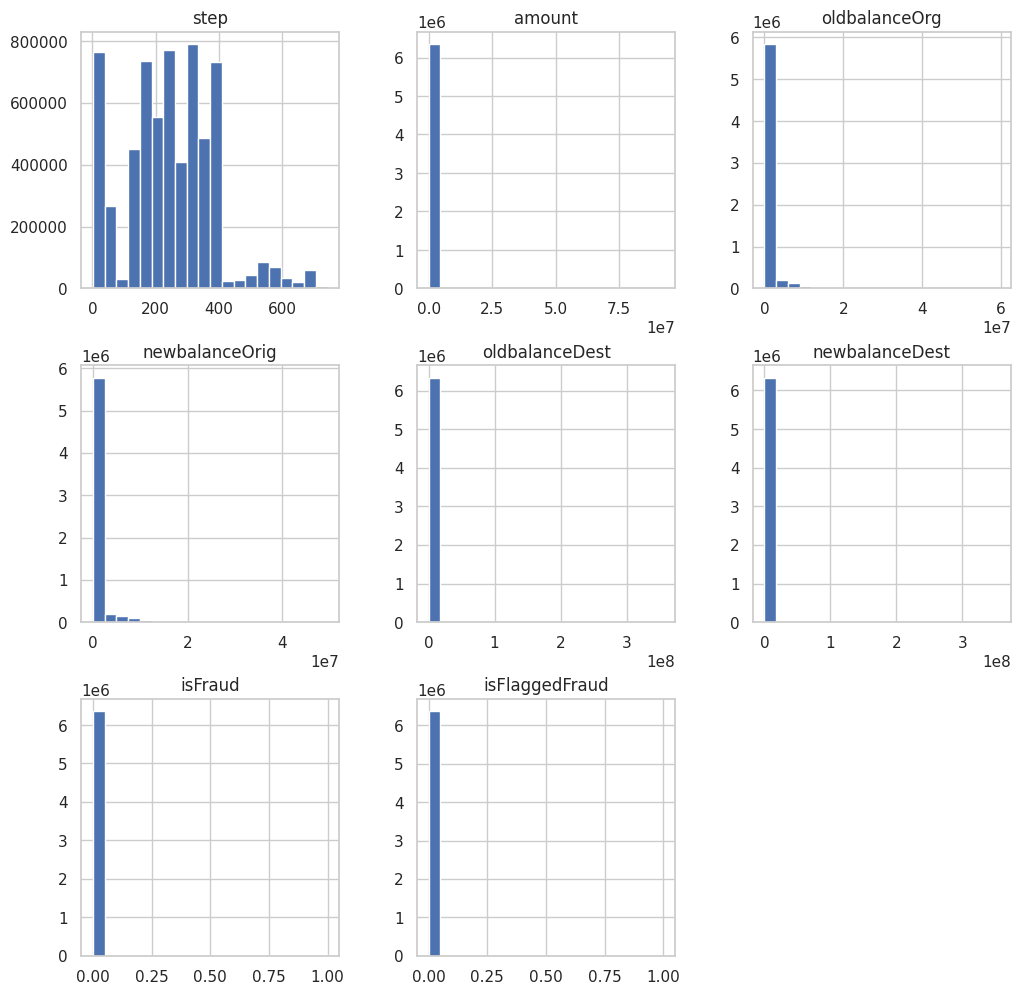

In [ ]:
numerical_data.hist(figsize=(12,12),bins=20)
plt.show()

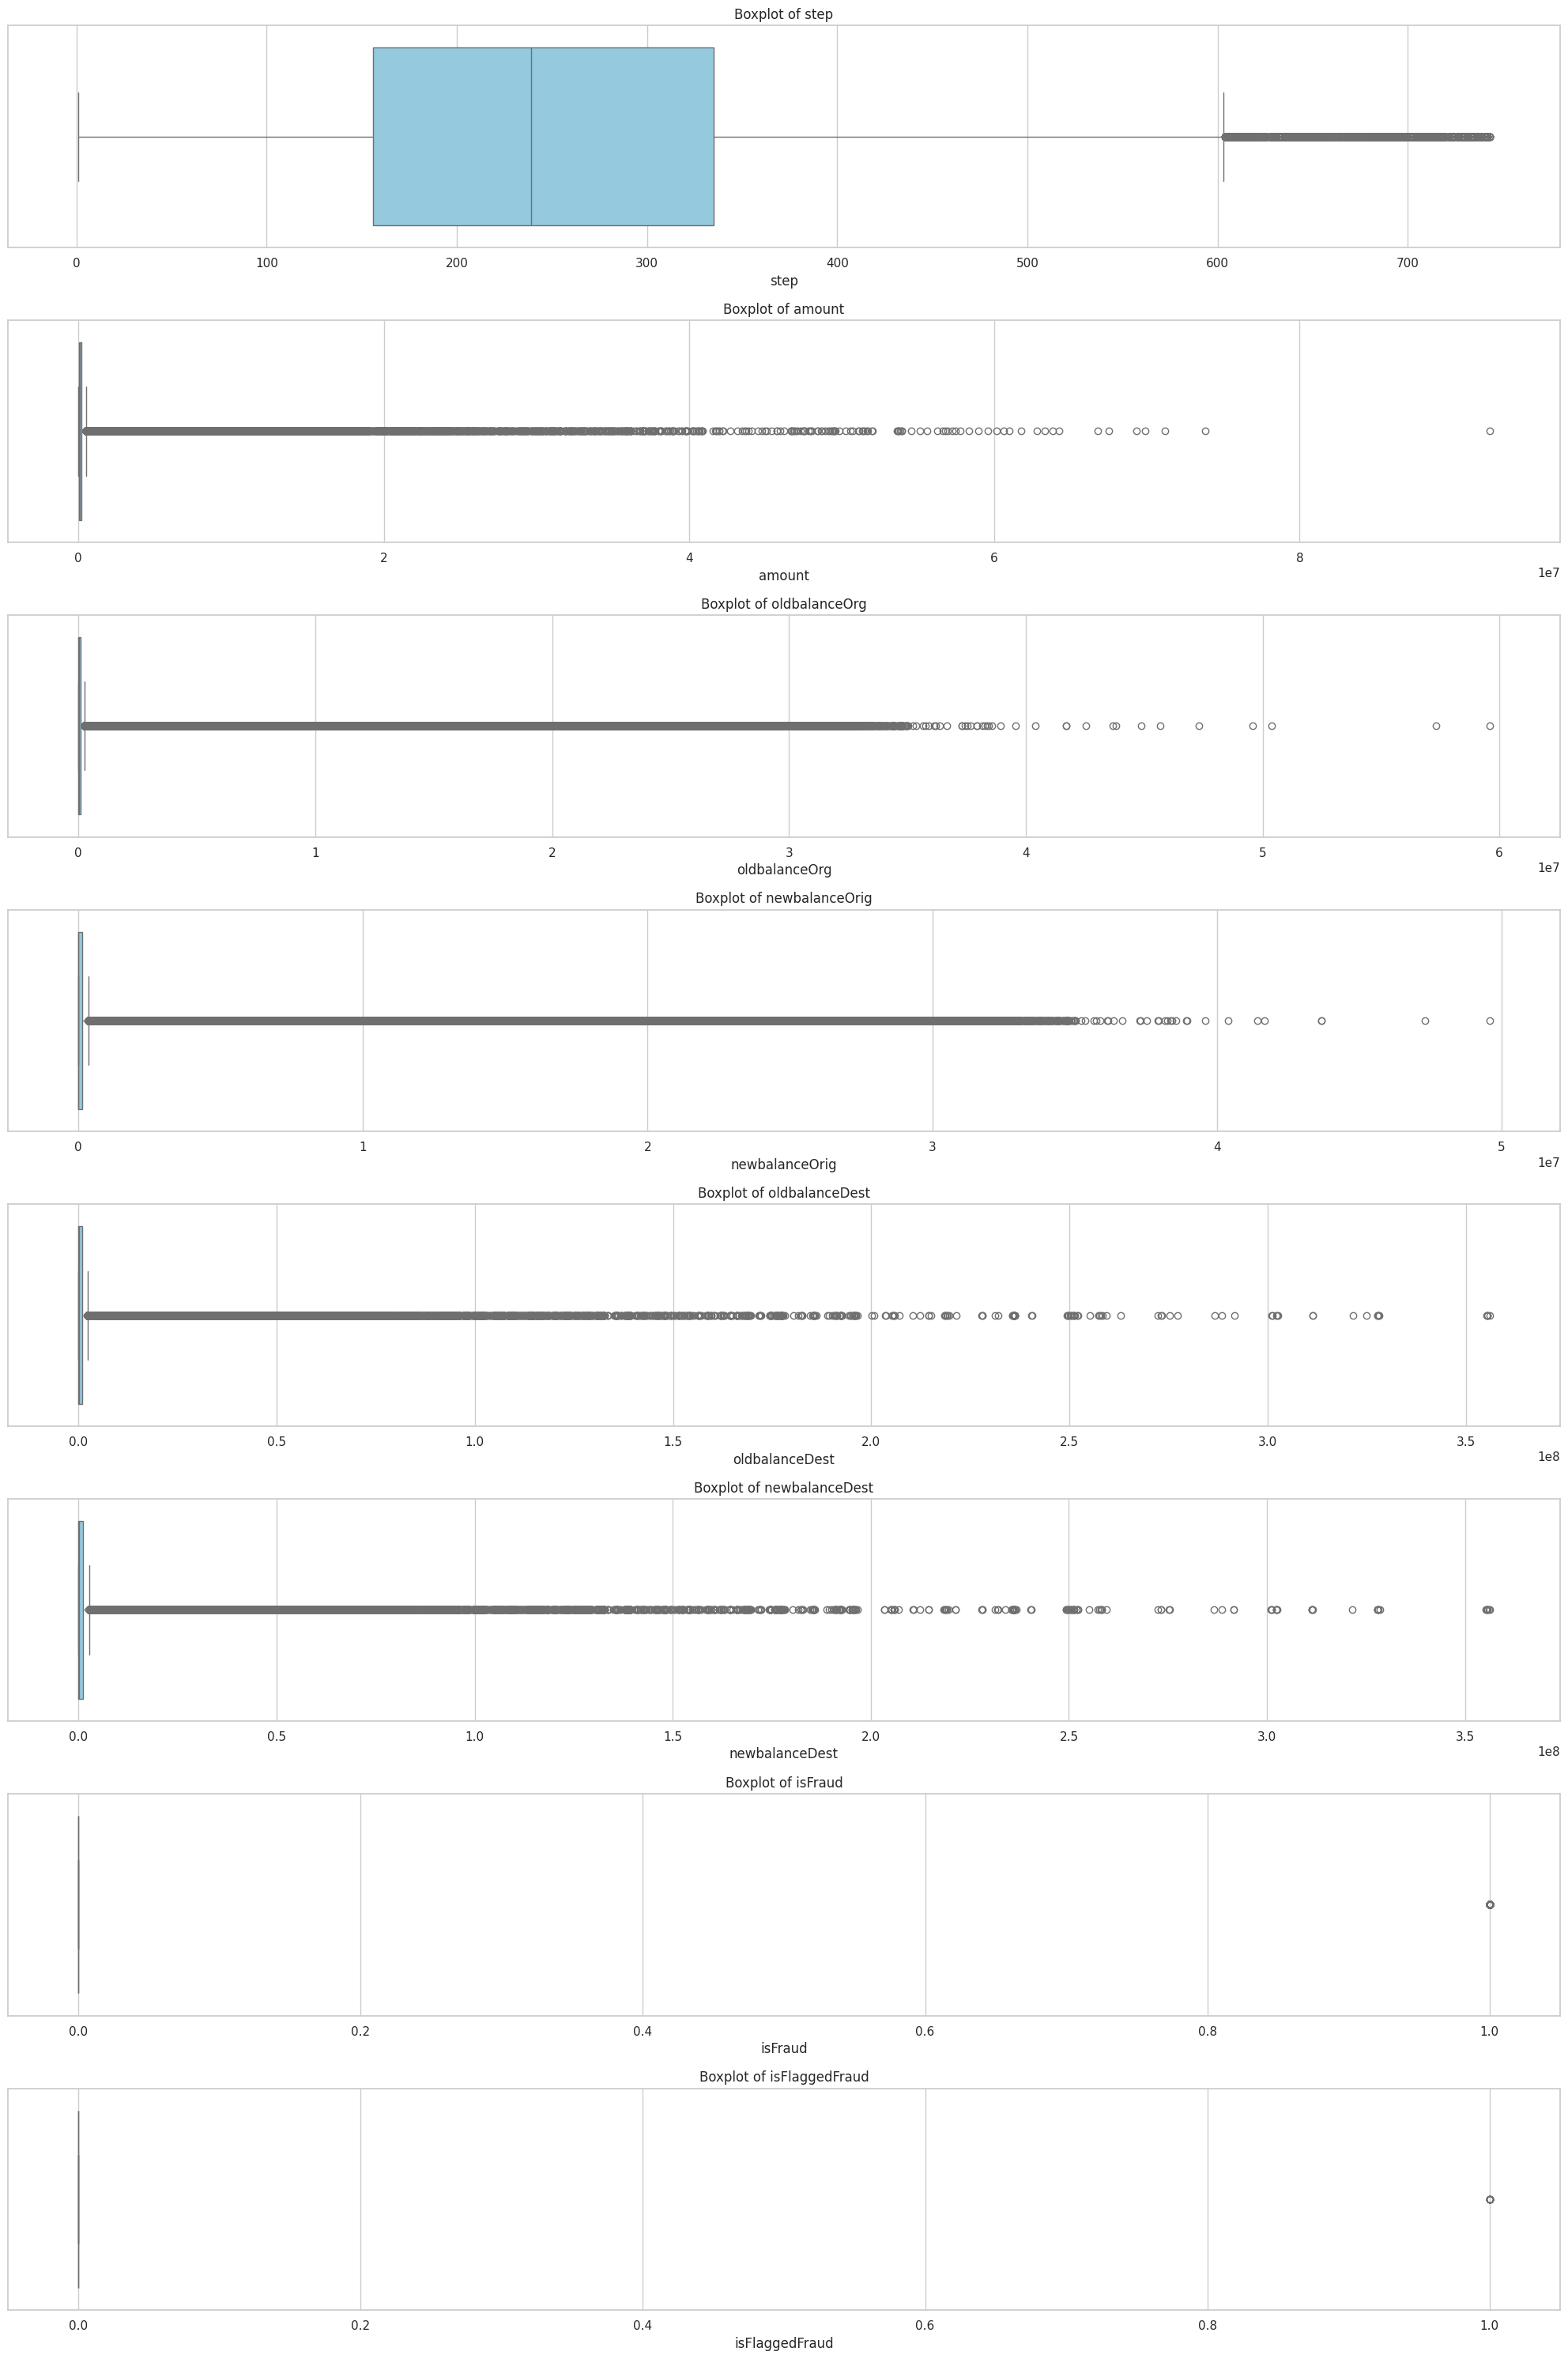

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for boxplot analysis
numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns

# Set up the figure
plt.figure(figsize=(20, 30))

# Plot boxplots for each numerical feature including the target variable 'OUTCOME'
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=dataset[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()

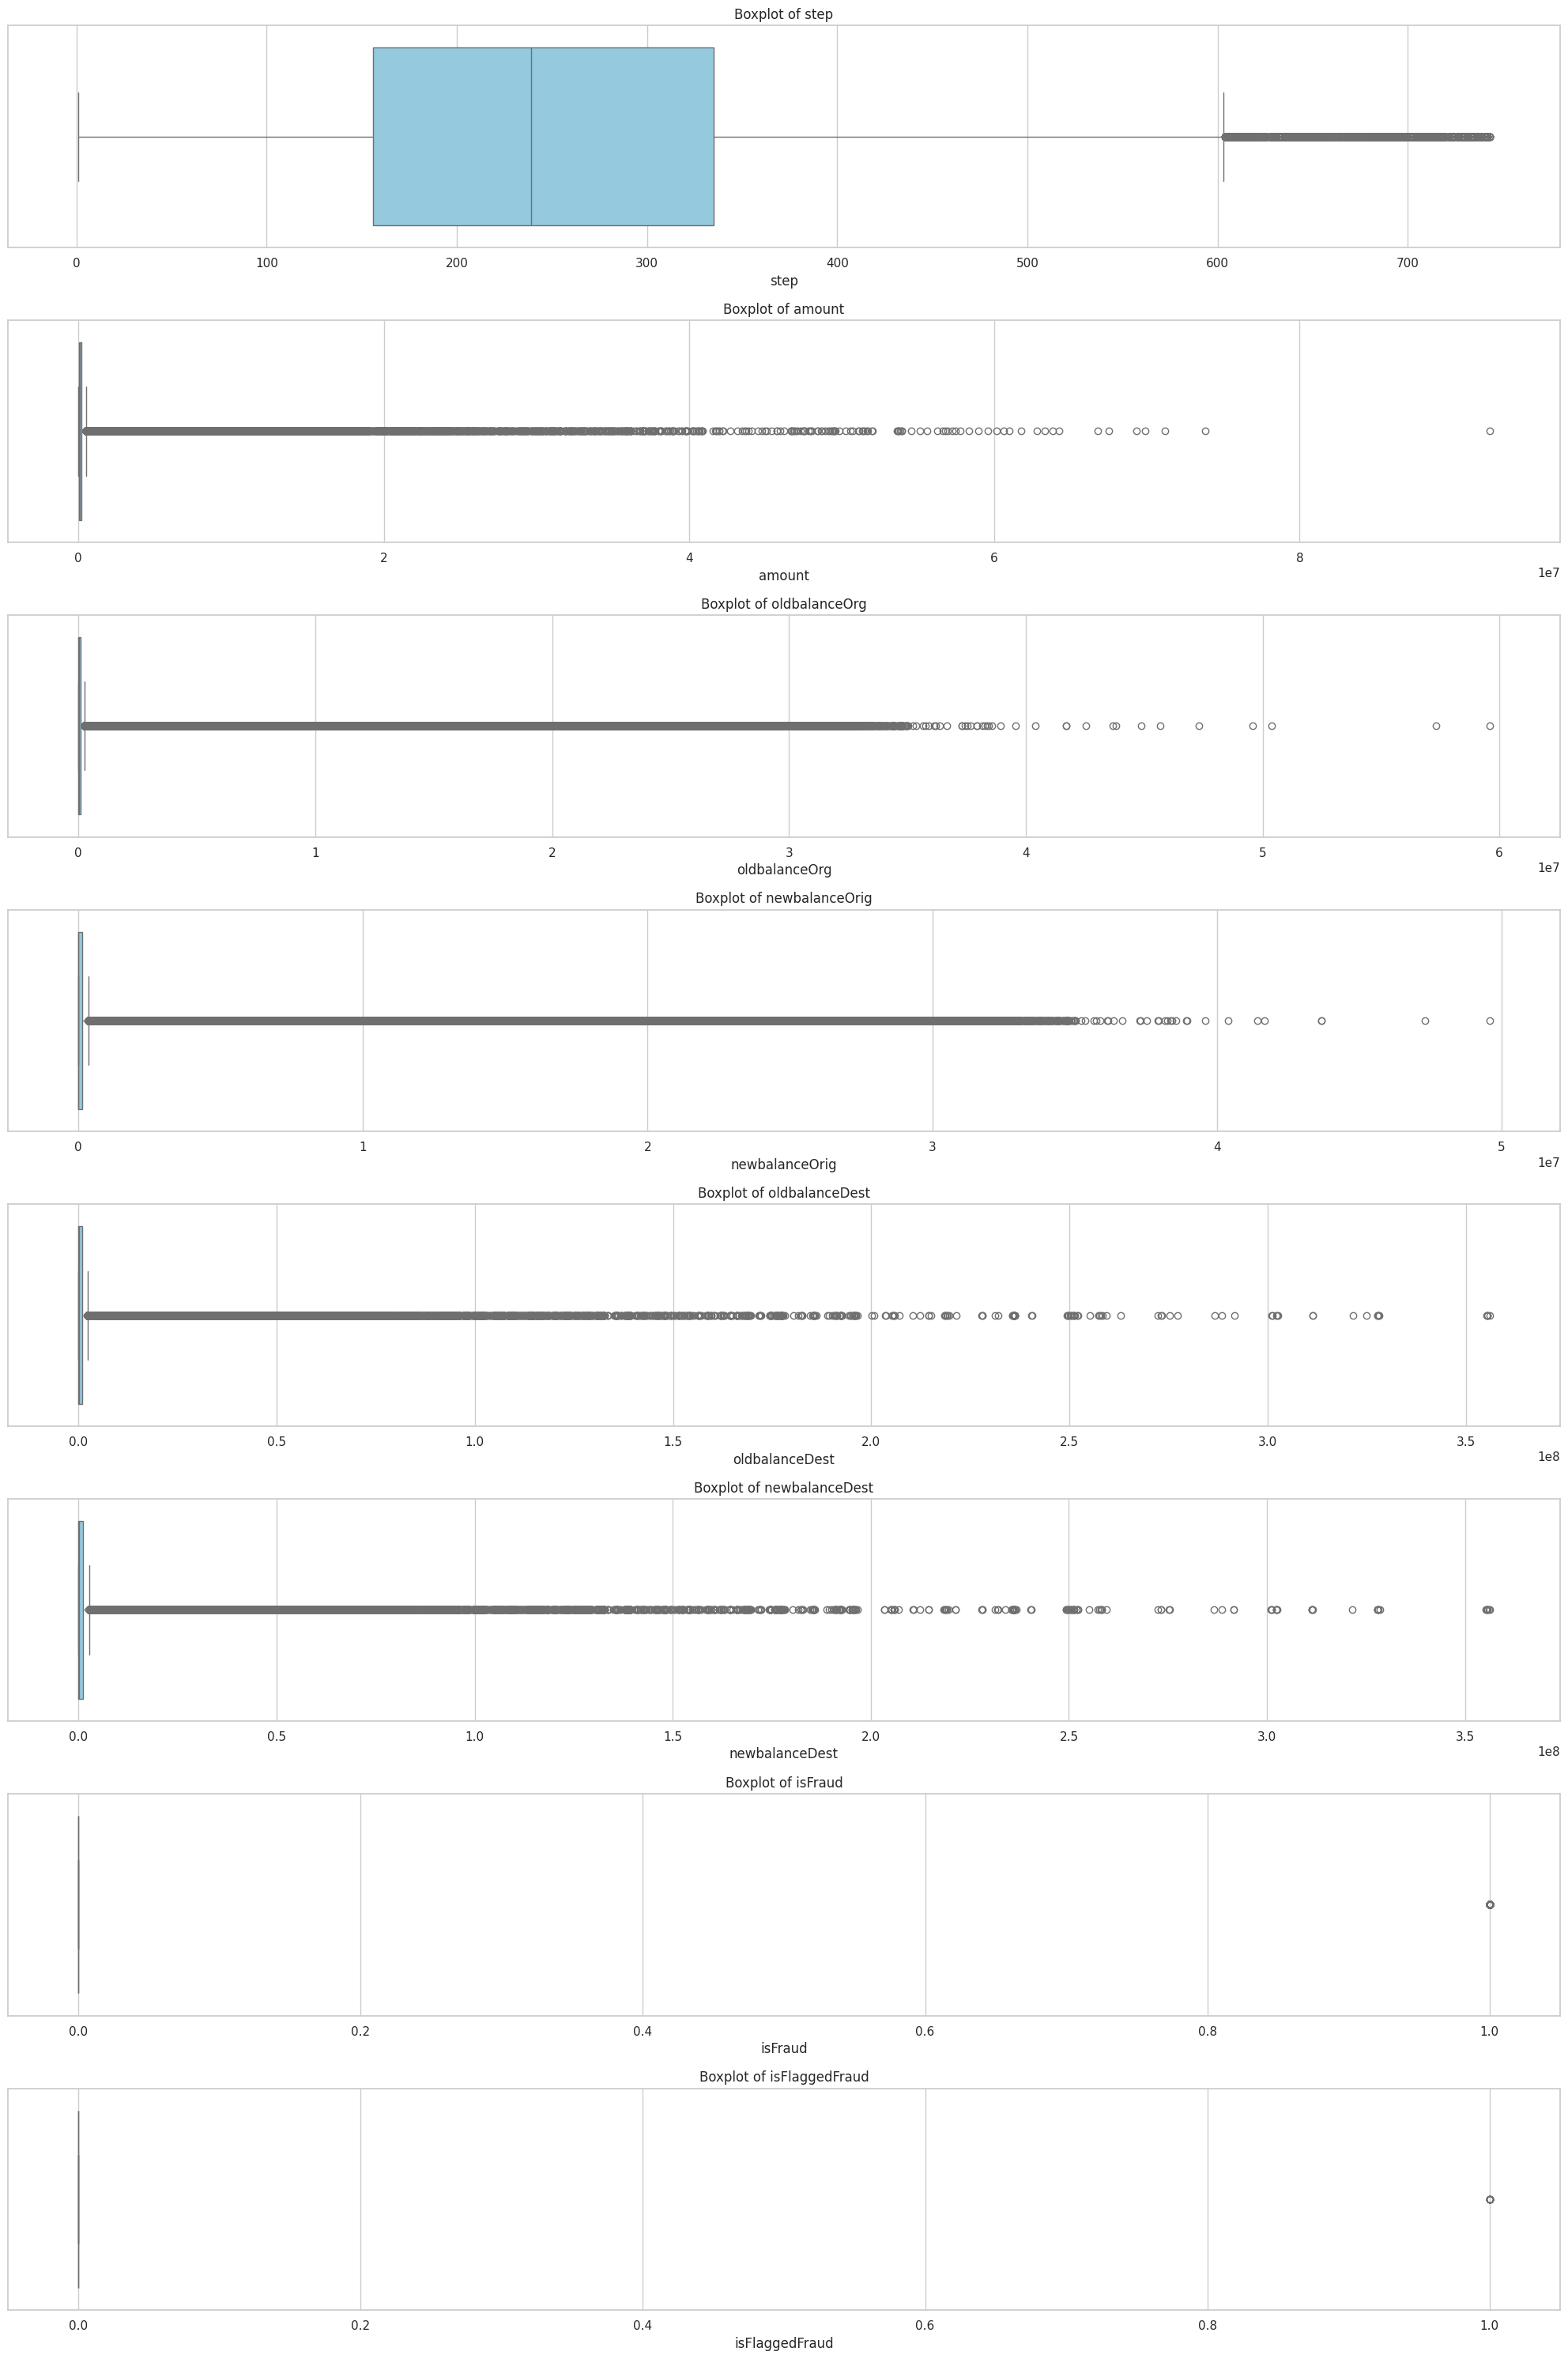

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for boxplot analysis
numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns

# Set up the figure
plt.figure(figsize=(20, 30))

# Plot boxplots for each numerical feature including the target variable 'OUTCOME'
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=dataset[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()

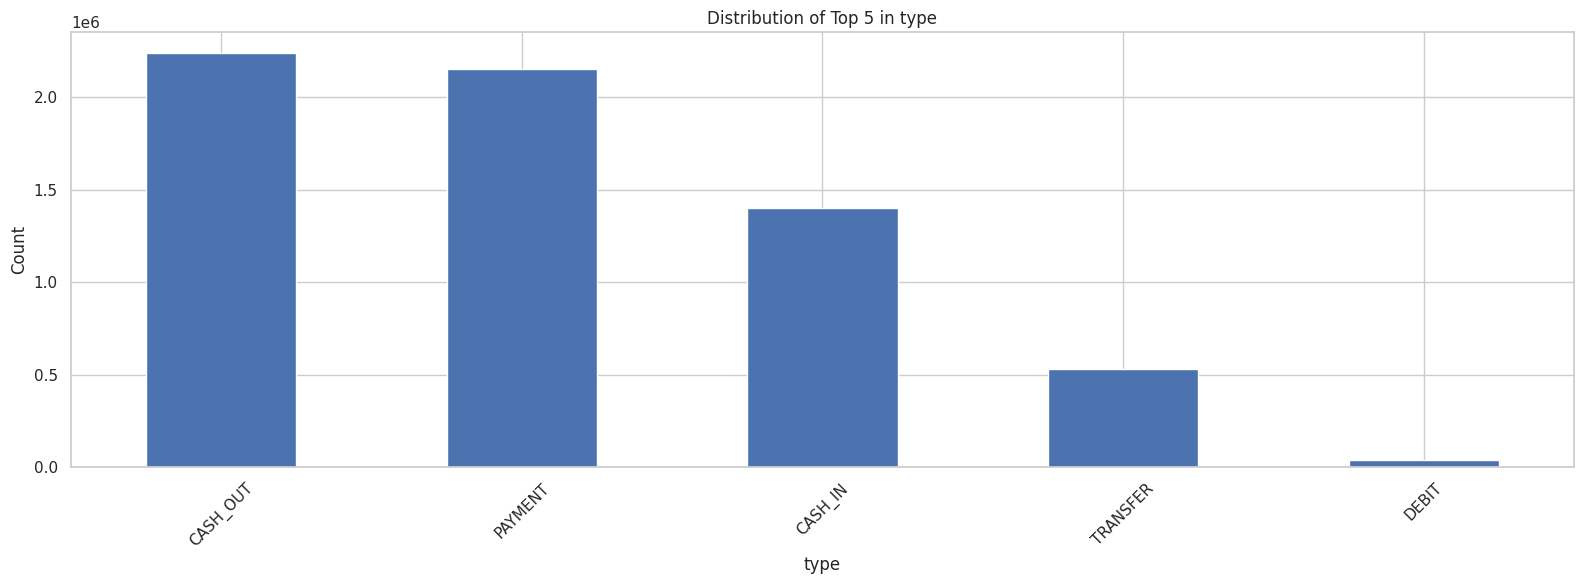

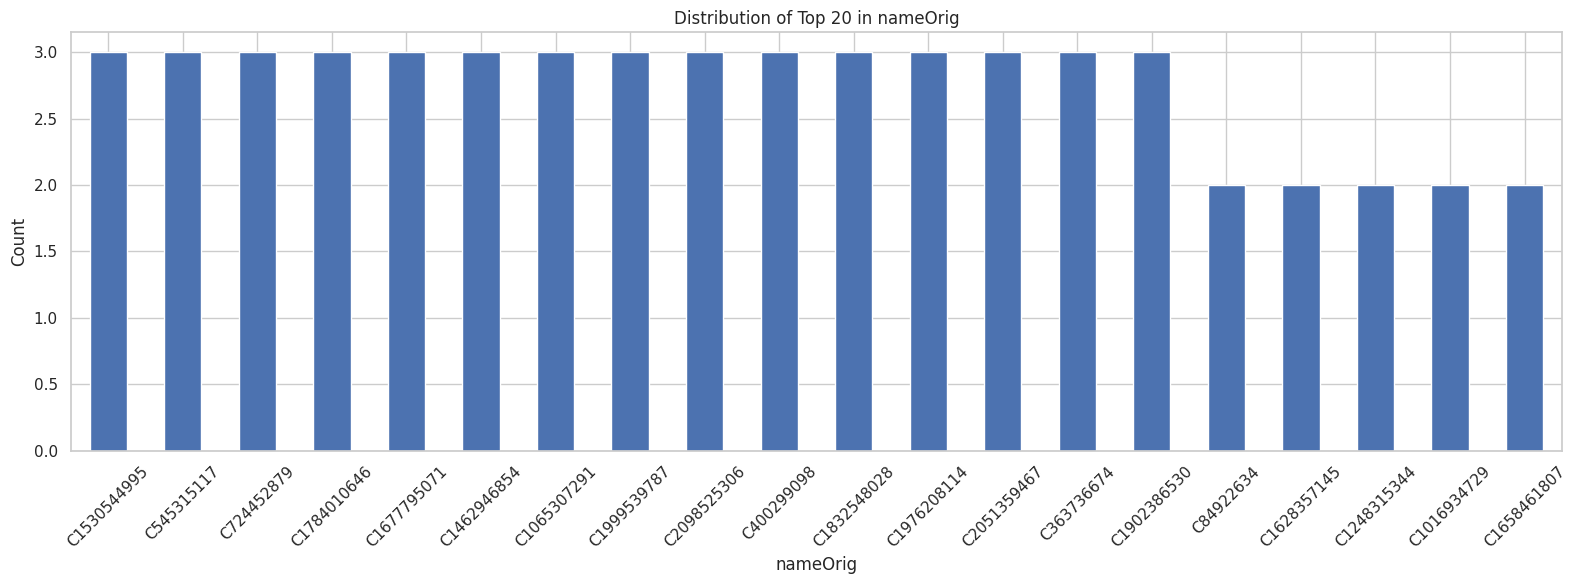

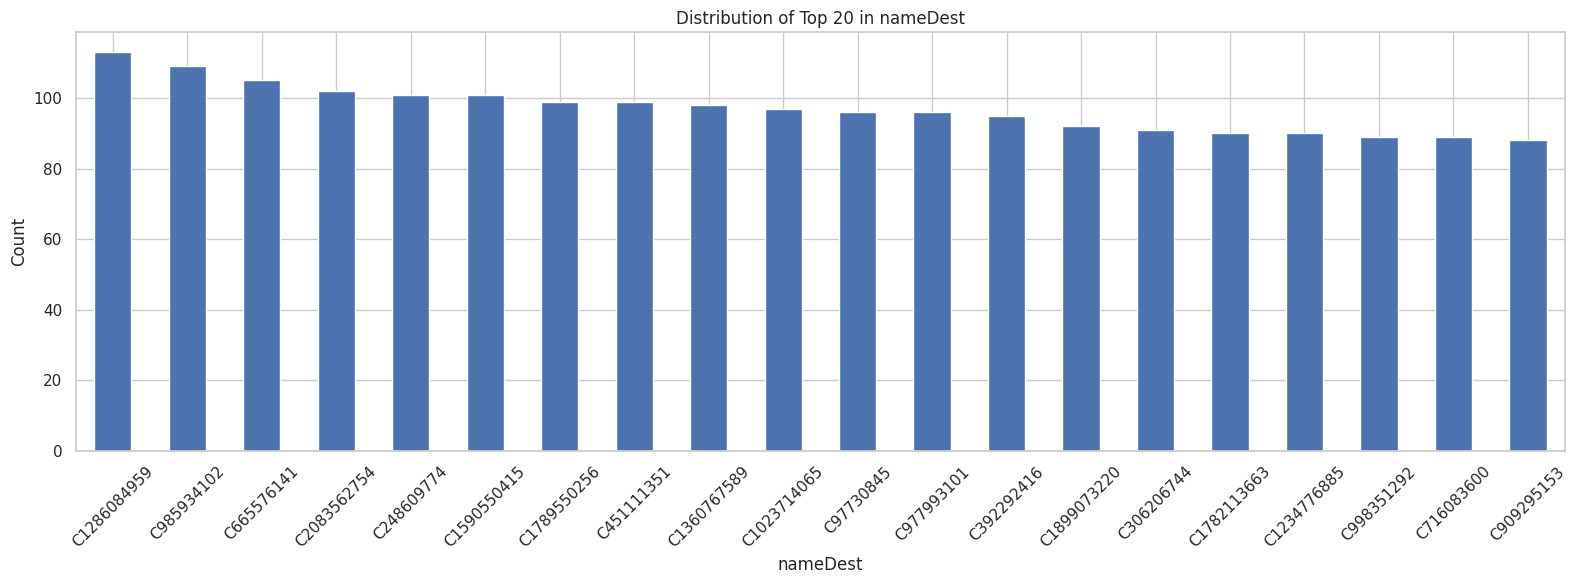

In [ ]:


for col in categorical_features:
    plt.figure(figsize=(16, 6))  # Wider figure
    if categorical_data[col].dropna().nunique() == 0:
        print(f"Skipping {col}: No valid categories.")
        continue

    # Sort by frequency, not index, then take top 20
    value_counts = categorical_data[col].value_counts().head(20)

    plt.title(f'Distribution of Top {len(value_counts)} in {col}')
    value_counts.plot(kind='bar', rot=45)  # Rotate x labels
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()




In [ ]:
numerical_data.isnull().sum()

,0
step,0
amount,0
oldbalanceOrg,0
newbalanceOrig,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0
isFlaggedFraud,0


In [ ]:
# unique values counts
unique_counts=categorical_data.nunique()
print(unique_counts)

type              5
nameOrig    6353307
nameDest    2722362
dtype: int64


In [ ]:
# Calculate the correlation matrix
correlation_matrix = numerical_data.corr()
correlation_matrix

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
step,1.000000,0.022373,-0.010058,-0.010299,0.027665,0.025888,0.031578,0.003277
amount,0.022373,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688,0.012295
oldbalanceOrg,-0.010058,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154,0.003835
newbalanceOrig,-0.010299,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148,0.003776
oldbalanceDest,0.027665,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885,-0.000513
newbalanceDest,0.025888,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535,-0.000529
isFraud,0.031578,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000,0.044109
isFlaggedFraud,0.003277,0.012295,0.003835,0.003776,-0.000513,-0.000529,0.044109,1.000000


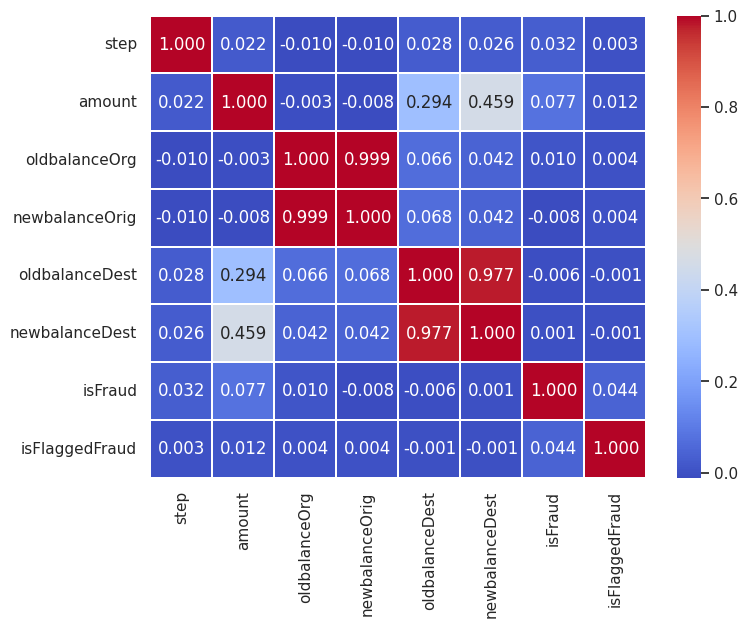

In [ ]:
# Plotting the heatmap for correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.3)
plt.show()

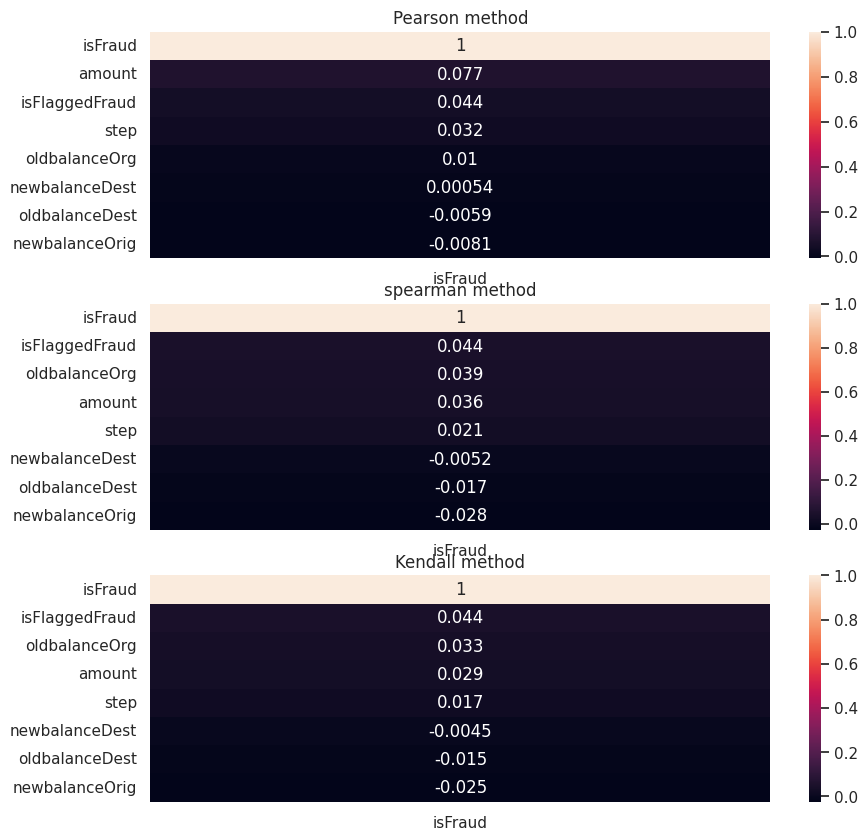

In [ ]:
fig, ax = plt.subplots(3,1, figsize=(10, 10))
## Correlation coefficient using different methods
# Assuming 'isFraud' is your target variable column
corr1 = numerical_data.corr('pearson')[['isFraud']].sort_values(by='isFraud', ascending=False)
corr2 = numerical_data.corr('spearman')[['isFraud']].sort_values(by='isFraud', ascending=False)
corr3 = numerical_data.corr('kendall')[['isFraud']].sort_values(by='isFraud', ascending=False)

#setting titles for each plot
ax[0].set_title('Pearson method')
ax[1].set_title('spearman method')
ax[2].set_title('Kendall method')

## Generating heatmaps of each methods
sns.heatmap(corr1, ax=ax[0], annot=True)
sns.heatmap(corr2, ax=ax[1], annot=True)
sns.heatmap(corr3, ax=ax[2], annot=True)

plt.show()

In [ ]:
#check Imbalance in data

#group instances based on the classes in isFraud variable
class_counts=dataset.groupby("isFraud").size()

columns=['outcome','count','percentage']
outcome=[0,1]
count=list()
percentage=list()

#Calculate the percentage of each value of the OUTCOME variable from total
for val in range(2):
    count.append(class_counts[val])
    percent=(class_counts[val]/len(dataset))*100 # Changed 105000 to len(dataset) for dynamic calculation
    percentage.append(percent)

# Convert the calulated values into a dataframe
imbalance_df=pd.DataFrame(list(zip(outcome,count,percentage)),columns=columns)
imbalance_df

,outcome,count,percentage
0,0,6354407,99.870918
1,1,8213,0.129082


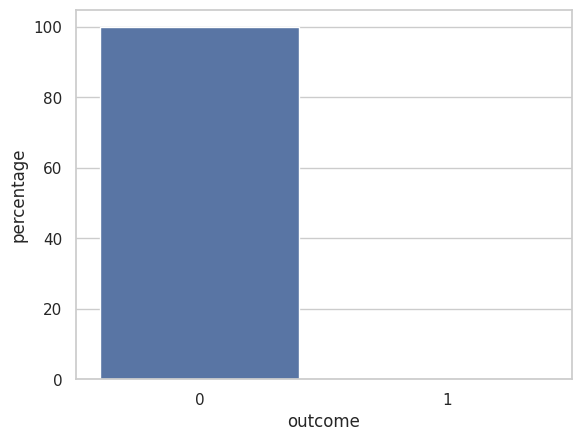

In [ ]:
sns.barplot(data=imbalance_df,x=imbalance_df['outcome'],y=imbalance_df['percentage'])
plt.show()

In [ ]:
numerical_data.plot(kind='kde', figsize=(14,14), subplots=True, layout=(6,2), title="Density plot of Numerical features", sharex=False)
plt.show()
